In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from fig_taxonomy import FIG_TAXONOMY

fig_root = 'FINAL_722_ALL_FIGS'


def save_fig(category, filename, **savefig_kwargs):
    dest_dir = Path(fig_root) / FIG_TAXONOMY[category]
    dest_dir.mkdir(parents=True, exist_ok=True)
    kwargs = {'bbox_inches': 'tight'}
    kwargs.update(savefig_kwargs)
    plt.savefig(dest_dir / filename, **kwargs)


In [ ]:
# new_alpha_sweep = pd.read_csv('./new_alpha_sweep.csv')
new_alpha_sweep = pd.read_csv('./alpha_sweep_results_722.csv')

# condition_to_urid_map = {
#     'B_pbr_ff2_moderate_del05': [1272310796451,
#                                 4965114072657,
#                                 8030859708906],
#     'E_utbn_ff2_moderate_del05': [2412930989432,
#                                 2582240140586,
#                                 5230109092875],
#     'A_svlt_ff2_moderate_del05': [6742345479376,
#                                 9793329286434,
#                                 9837104696216],
#     'A_svlt_ff2_moderate_del0': [1949496656499,
#                                 2477370842873,
#                                 7393906670185],
#     'D_lbd_ff2_moderate_del05': [5670243150121,
#                                 6035962513529,
#                                 7073674028991]
# }

condition_to_urid_map = {
    'I_null_baseline_percelltype_ff_del0': [3466963405706],
    'J_biograded_normalized_biased_percelltype_ff_del0': [5431691972451],
    'K_progressive_bottleneck_percelltype_ff_del0': [3578166838675],
    'L_extended_persistent_clustered_percelltype_ff_del0': [1059866531831],
}

urid_to_condition_map = {urid:condition for condition, urid_list in condition_to_urid_map.items()
                         for urid in urid_list}


new_alpha_sweep['condition'] = new_alpha_sweep['urid'].map(urid_to_condition_map)

In [17]:
new_alpha_sweep

,urid,timepoint,param_combo,alpha,roc_auc,pr_auc,f1_hard,precision,recall,tp,fp,tn,fn,pred_pos_frac,n_cells,n_clades,best_logL,condition
0,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.00,0.500000,0.739130,0.000000,0.000000,0.000000,0,0,60,55,0.0000,115,7,-133.2242,B_pbr_ff2_moderate_del05
1,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.25,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2201,B_pbr_ff2_moderate_del05
2,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.50,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2424,B_pbr_ff2_moderate_del05
3,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.75,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2927,B_pbr_ff2_moderate_del05
4,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,1.00,0.781818,0.789973,0.674847,0.509259,1.000000,55,53,7,0,0.9391,115,7,-133.3754,B_pbr_ff2_moderate_del05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.00,0.500000,0.737776,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6055.9128,D_lbd_ff2_moderate_del05
1346,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.25,0.519630,0.519318,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6027.1822,D_lbd_ff2_moderate_del05
1347,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.50,0.525450,0.522606,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6021.1689,D_lbd_ff2_moderate_del05
1348,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.75,0.525633,0.522786,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6021.7242,D_lbd_ff2_moderate_del05


In [18]:
across_alphas = new_alpha_sweep.groupby(['condition', 'param_combo', 'alpha'])[['pr_auc']].mean().reset_index()

In [19]:
across_alphas

,condition,param_combo,alpha,pr_auc
0,A_svlt_ff2_moderate_del0,20clade_topological_treedist_gt,0.00,0.749525
1,A_svlt_ff2_moderate_del0,20clade_topological_treedist_gt,0.25,0.993015
2,A_svlt_ff2_moderate_del0,20clade_topological_treedist_gt,0.50,0.985814
3,A_svlt_ff2_moderate_del0,20clade_topological_treedist_gt,0.75,0.996412
4,A_svlt_ff2_moderate_del0,20clade_topological_treedist_gt,1.00,0.993322
...,...,...,...,...
70,E_utbn_ff2_moderate_del05,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.00,0.752663
71,E_utbn_ff2_moderate_del05,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.25,0.786053
72,E_utbn_ff2_moderate_del05,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.50,0.800435
73,E_utbn_ff2_moderate_del05,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.75,0.796568


/Users/aidancook/opt/anaconda3/envs/sim_em_env/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


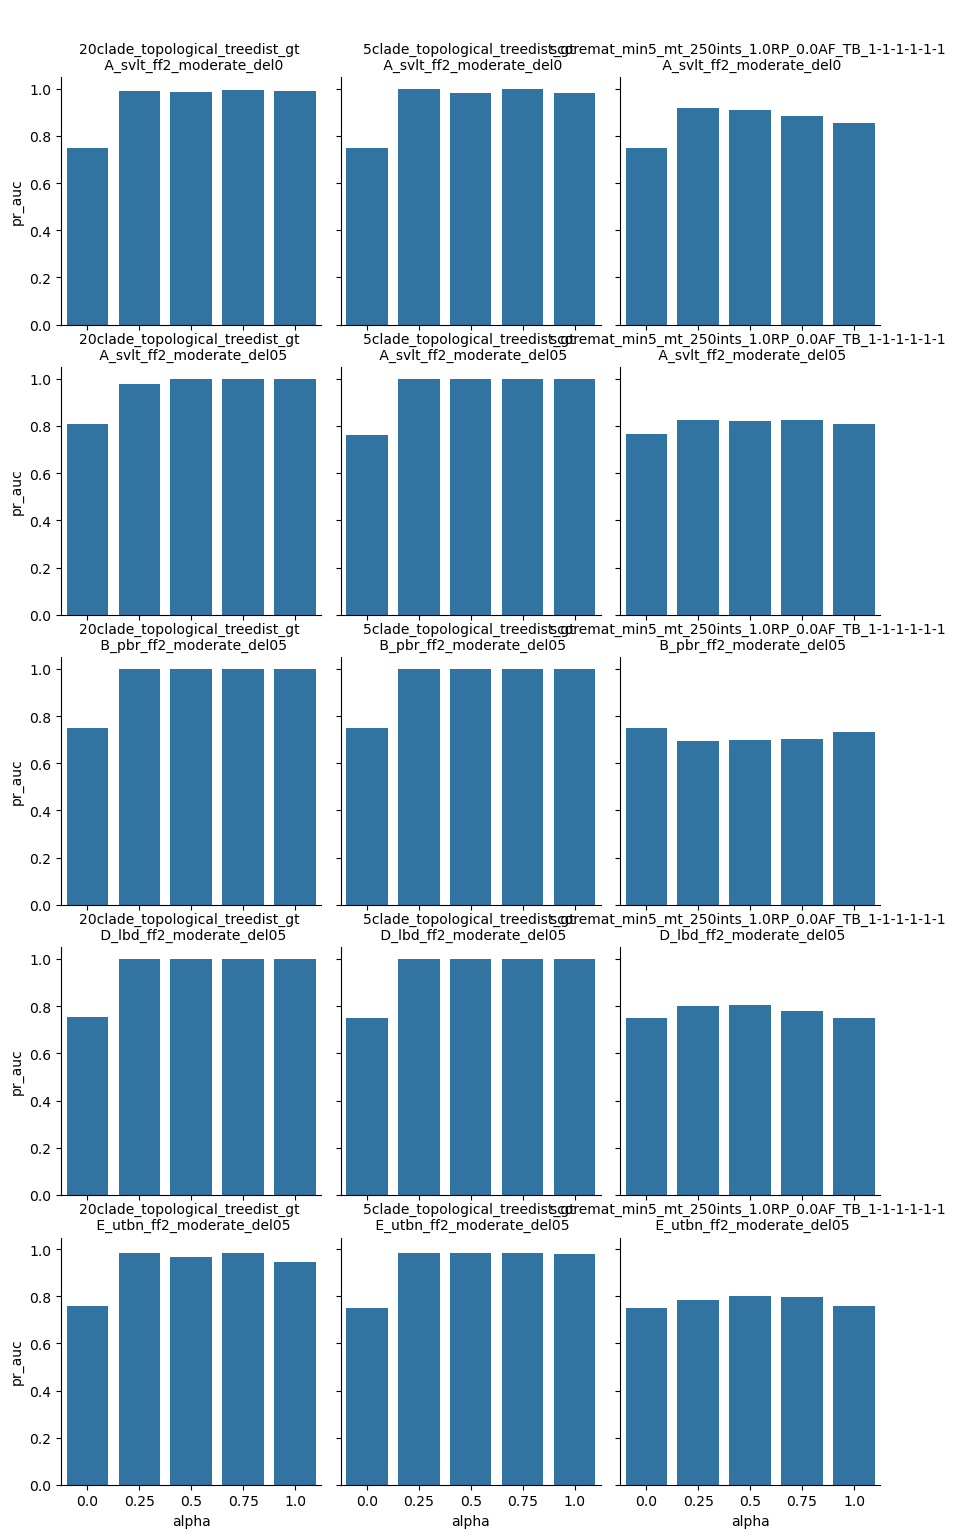

In [24]:
g = sns.FacetGrid(across_alphas, col = 'param_combo', row = 'condition')
g.map(sns.barplot, 'alpha', 'pr_auc')
g.set_titles('\n\n{col_name} \n {row_name}')

In [ ]:
sns.barplot(across_alphas, x = 'condition', hue = 'param_combo', y = 'pr_auc')

In [3]:
new_alpha_sweep

,urid,timepoint,param_combo,alpha,roc_auc,pr_auc,f1_hard,precision,recall,tp,fp,tn,fn,pred_pos_frac,n_cells,n_clades,best_logL
0,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.00,0.500000,0.739130,0.000000,0.000000,0.000000,0,0,60,55,0.0000,115,7,-133.2242
1,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.25,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2201
2,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.50,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2424
3,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.75,0.781818,0.789973,0.723077,0.626667,0.854545,47,28,32,8,0.6522,115,7,-133.2927
4,1272310796451,8,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,1.00,0.781818,0.789973,0.674847,0.509259,1.000000,55,53,7,0,0.9391,115,7,-133.3754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.00,0.500000,0.737776,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6055.9128
1346,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.25,0.519630,0.519318,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6027.1822
1347,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.50,0.525450,0.522606,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6021.1689
1348,7073674028991,13,scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-...,0.75,0.525633,0.522786,0.000000,0.000000,0.000000,0,0,1802,1634,0.0000,3436,20,-6021.7242


In [ ]:
# === Comprehensive Analysis ===

combo_labels = {
    '5clade_topological_treedist_gt': 'gt5',
    '20clade_topological_treedist_gt': 'gt20',
    'scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-1-1-1': 'scoremat_min5',
}
# condition_short = {
#     'B_pbr_ff2_moderate_del05':  'B_pbr',
#     'E_utbn_ff2_moderate_del05': 'E_utbn',
#     'A_svlt_ff2_moderate_del05': 'A_svlt_del05',
#     'A_svlt_ff2_moderate_del0':  'A_svlt_del0',
#     'D_lbd_ff2_moderate_del05':  'D_lbd',
# }
condition_short = {
    'I_null_baseline_percelltype_ff_del0': 'I',
    'J_biograded_normalized_biased_percelltype_ff_del0': 'J',
    'K_progressive_bottleneck_percelltype_ff_del0': 'K',
    'L_extended_persistent_clustered_percelltype_ff_del0': 'L',
}

df = new_alpha_sweep.copy()
df['combo'] = df['param_combo'].map(combo_labels)
df['cond_short'] = df['condition'].map(condition_short)
df['logL_per_cell'] = df['best_logL'] / df['n_cells']

print(f'Rows: {len(df)}  |  urids: {df["urid"].nunique()}  |  timepoints: {sorted(df["timepoint"].unique())}  |  alpha values: {sorted(df["alpha"].unique())}')
print('Combos:', df['combo'].unique())
print('Conditions:', df['cond_short'].unique())

## 1. ROC-AUC vs alpha - main result

Mean ROC-AUC across replicates and timepoints. Each combo (gt5, gt20, scoremat_min5) is a separate line per condition panel.

In [ ]:
# combo_order = ['gt5', 'gt20', 'scoremat_min5']
# combo_colors = {'gt5': '#2563EB', 'gt20': '#7C3AED', 'scoremat_min5': '#DC2626'}
# cond_order = ['B_pbr', 'E_utbn', 'A_svlt_del05', 'A_svlt_del0', 'D_lbd']
combo_order = ['gt5', 'scoremat_min5']
combo_colors = {'gt5': '#2563EB', 'scoremat_min5': '#DC2626'}
cond_order = ['I', 'J', 'K', 'L']

for cond in cond_order:
    sub = df[df['cond_short'] == cond]
    fig, ax = plt.subplots(figsize = (4, 3.5))
    sns.lineplot(
        data = sub, x = 'alpha', y = 'roc_auc', hue = 'combo',
        hue_order = combo_order, palette = combo_colors,
        marker = 'o', errorbar = ('pi', 100), ax = ax
    )
    ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.8)
    ax.axhline(1.0, ls = '--', color = 'gray', lw = 0.8)
    ax.set_title(cond, fontsize = 10)
    ax.set_xlabel('alpha', fontsize = 9)
    ax.set_ylabel('ROC-AUC (mean +/- range)', fontsize = 9)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([0, .25, .5, .75, 1], fontsize = 7)
    if ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.tight_layout()
    fname = f'roc_auc_vs_alpha_{cond}.pdf'
    save_fig('alpha_sweep/roc_auc', fname)
    plt.close(fig)
    print(f'saved {fname}')

fig_leg, ax_leg = plt.subplots(figsize = (2.5, 1.5))
for combo in combo_order:
    ax_leg.plot([], [], color = combo_colors[combo], lw = 2, marker = 'o', markersize = 5, label = combo)
ax_leg.axis('off')
ax_leg.legend(fontsize = 9, loc = 'center')
fig_leg.tight_layout()
save_fig('legends', 'legend_combo.pdf')
plt.close(fig_leg)
print('saved legend_combo.pdf')

In [ ]:
# PR-AUC analog of the ROC-AUC-vs-alpha-per-condition plots above (reuses combo_order / combo_colors / legend_combo.pdf)
for cond in cond_order:
    sub = df[df['cond_short'] == cond]
    fig, ax = plt.subplots(figsize = (4, 3.5))
    sns.lineplot(
        data = sub, x = 'alpha', y = 'pr_auc', hue = 'combo',
        hue_order = combo_order, palette = combo_colors,
        marker = 'o', errorbar = ('pi', 100), ax = ax
    )
    ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.8)
    ax.axhline(1.0, ls = '--', color = 'gray', lw = 0.8)
    ax.set_title(cond, fontsize = 10)
    ax.set_xlabel('alpha', fontsize = 9)
    ax.set_ylabel('PR-AUC (mean +/- range)', fontsize = 9)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([0, .25, .5, .75, 1], fontsize = 7)
    if ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.tight_layout()
    fname = f'pr_auc_vs_alpha_{cond}.pdf'
    save_fig('alpha_sweep/pr_auc', fname)
    plt.close(fig)
    print(f'saved {fname}')

## 2. F1 vs alpha - hard-label quality

ROC-AUC measures soft-score ranking; F1 measures whether the EM's hard labels (0/1) are correct. Many cases with ROC-AUC=1.0 still have F1=0 because the EM collapses to all-uninduced or all-induced predictions.

In [ ]:
for cond in cond_order:
    sub = df[df['cond_short'] == cond]
    fig, ax = plt.subplots(figsize = (4, 3.5))
    sns.lineplot(
        data = sub, x = 'alpha', y = 'f1_hard', hue = 'combo',
        hue_order = combo_order, palette = combo_colors,
        marker = 'o', errorbar = ('pi', 100), ax = ax
    )
    ax.axhline(0.667, ls = ':', color = 'orange', lw = 0.8)
    ax.set_title(cond, fontsize = 10)
    ax.set_xlabel('alpha', fontsize = 9)
    ax.set_ylabel('F1 hard (mean +/- range)', fontsize = 9)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([0, .25, .5, .75, 1], fontsize = 7)
    if ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.tight_layout()
    fname = f'f1_vs_alpha_{cond}.pdf'
    save_fig('alpha_sweep/f1_and_logl', fname)
    plt.close(fig)
    print(f'saved {fname}')

degenerate = df[df['pred_pos_frac'].isin([0.0, 1.0])]
print(f'Degenerate hard-label predictions: {len(degenerate)}/{len(df)} = {len(degenerate)/len(df):.1%}')
print(degenerate.groupby(['combo', 'pred_pos_frac']).size().to_string())

## 3. GT5 vs GT20 — are they different?

Direct scatter: ROC-AUC of gt5 vs gt20 at matched urid × timepoint × α.

In [ ]:
key = ['urid', 'timepoint', 'alpha']
gt5_vals  = df[df['combo'] == 'gt5' ][key + ['roc_auc', 'f1_hard', 'logL_per_cell']].rename(columns = {'roc_auc': 'roc_gt5', 'f1_hard': 'f1_gt5', 'logL_per_cell': 'logL_gt5'})
gt20_vals = df[df['combo'] == 'gt20'][key + ['roc_auc', 'f1_hard', 'logL_per_cell']].rename(columns = {'roc_auc': 'roc_gt20', 'f1_hard': 'f1_gt20', 'logL_per_cell': 'logL_gt20'})
gt_cmp = gt5_vals.merge(gt20_vals, on = key)

if len(gt_cmp) == 0:
    print('[skip] no gt20 rows in this alpha sweep run (only gt5 + scoremat_min5 were computed) -- skipping gt5-vs-gt20 comparison')
else:
    metric_pairs = [
        ('roc_gt5',  'roc_gt20',  'ROC-AUC',    'ROC-AUC: GTTC (5 clades) vs GTTC (20 clades)'),
        ('f1_gt5',   'f1_gt20',   'F1',          'F1: GTTC (5 clades) vs GTTC (20 clades)'),
        ('logL_gt5', 'logL_gt20', 'logL / cell', 'logL/cell: GTTC (5 clades) vs GTTC (20 clades)'),
    ]

    norm = mpl.colors.Normalize(vmin = 0, vmax = 1)

    for x_col, y_col, metric_name, title in metric_pairs:
        fig, ax = plt.subplots(figsize = (5, 5))
        sc = ax.scatter(gt_cmp[x_col], gt_cmp[y_col],
                        c = gt_cmp['alpha'], cmap = 'viridis', norm = norm,
                        alpha = 0.5, s = 20)
        lo = min(gt_cmp[x_col].min(), gt_cmp[y_col].min())
        hi = max(gt_cmp[x_col].max(), gt_cmp[y_col].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw = 0.8)
        ax.set_xlabel(f'{metric_name} (GTTC 5 clades)', fontsize = 11)
        ax.set_ylabel(f'{metric_name} (GTTC 20 clades)', fontsize = 11)
        ax.set_title(title, fontsize = 12, pad = 10)
        cb = fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap = 'viridis'), ax = ax)
        cb.set_label('alpha', fontsize = 11)
        ax.spines[['top', 'right']].set_visible(False)
        fig.tight_layout()
        safe = metric_name.replace('/', '_per_').replace(' ', '_')
        fname = f'gt5_vs_gt20_{safe}.pdf'
        save_fig('purity_and_ari/resolution_comparison', fname)
        plt.close(fig)
        print(f'saved {fname}')

    diff = gt_cmp[gt_cmp['roc_gt5'] != gt_cmp['roc_gt20']]
    print(f'Rows where roc_gt5 != roc_gt20: {len(diff)}/{len(gt_cmp)} = {len(diff)/len(gt_cmp):.1%}')
    print('\nMean logL/cell:')
    print(f'  gt5:  {gt_cmp["logL_gt5"].mean():.4f}')
    print(f'  gt20: {gt_cmp["logL_gt20"].mean():.4f}  (more negative = worse fit)')

## 4. Minimum alpha needed for ROC-AUC >= 0.9

For each urid x combo, what is the smallest alpha that pushes mean ROC-AUC (across timepoints) above 0.9?  
Cells are blank where no alpha achieved this threshold.

In [ ]:
urid_alpha = df.groupby(['urid', 'cond_short', 'combo', 'alpha'])['roc_auc'].mean().reset_index()

def min_alpha_for_threshold(grp, thresh = 0.9):
    good = grp[grp['roc_auc'] >= thresh]
    return good['alpha'].min() if len(good) > 0 else np.nan

min_alpha = (
    urid_alpha
    .groupby(['urid', 'cond_short', 'combo'])
    .apply(min_alpha_for_threshold)
    .reset_index(name = 'min_alpha_09')
)

pivot = min_alpha.pivot_table(index = ['cond_short', 'urid'], columns = 'combo', values = 'min_alpha_09')
pivot = pivot.reindex(columns = combo_order)  # reindex (not [] ) so an all-NaN combo isn't dropped

fig, ax = plt.subplots(figsize = (7, 8))
cmap = plt.cm.RdYlGn_r
masked = np.ma.masked_invalid(pivot.values.astype(float))
im = ax.imshow(masked, cmap = cmap, vmin = 0, vmax = 1, aspect = 'auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize = 10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{c}  {u}' for c, u in pivot.index], fontsize = 7)

for i in range(masked.shape[0]):
    for j in range(masked.shape[1]):
        val = pivot.values[i, j]
        txt = f'{val:.2f}' if not np.isnan(val) else '-'
        ax.text(j, i, txt, ha = 'center', va = 'center', fontsize = 8,
                color = 'black' if (np.isnan(val) or val > 0.4) else 'white')

plt.colorbar(im, ax = ax, label = 'min alpha for mean ROC-AUC >= 0.9\n(- = never achieved)')
ax.set_title('Min alpha to reach ROC-AUC >= 0.9\n(averaged over timepoints 8-13)', fontsize = 11)
fig.tight_layout()
save_fig('alpha_sweep/roc_auc', 'min_alpha_heatmap.pdf')
plt.close(fig)
print('saved min_alpha_heatmap.pdf')

n_never = min_alpha['min_alpha_09'].isna().sum()
print(f'urid x combo pairs that never reach ROC-AUC >= 0.9: {n_never}/{len(min_alpha)}')
print('\nBy combo:')
print(min_alpha.groupby('combo')['min_alpha_09'].agg(
    never_achieves = lambda x: x.isna().sum(),
    median_min_alpha = 'median'
).to_string())

In [ ]:
# PR-AUC analog of the ROC-AUC min-alpha-to-threshold heatmap above
urid_alpha_pr2 = df.groupby(['urid', 'cond_short', 'combo', 'alpha'])['pr_auc'].mean().reset_index()

def min_alpha_for_threshold_pr(grp, thresh = 0.9):
    good = grp[grp['pr_auc'] >= thresh]
    return good['alpha'].min() if len(good) > 0 else np.nan

min_alpha_pr = (
    urid_alpha_pr2
    .groupby(['urid', 'cond_short', 'combo'])
    .apply(min_alpha_for_threshold_pr)
    .reset_index(name = 'min_alpha_09')
)

pivot_pr = min_alpha_pr.pivot_table(index = ['cond_short', 'urid'], columns = 'combo', values = 'min_alpha_09')
pivot_pr = pivot_pr.reindex(columns = combo_order)

fig, ax = plt.subplots(figsize = (7, 8))
cmap = plt.cm.RdYlGn_r
masked = np.ma.masked_invalid(pivot_pr.values.astype(float))
im = ax.imshow(masked, cmap = cmap, vmin = 0, vmax = 1, aspect = 'auto')

ax.set_xticks(range(len(pivot_pr.columns)))
ax.set_xticklabels(pivot_pr.columns, fontsize = 10)
ax.set_yticks(range(len(pivot_pr.index)))
ax.set_yticklabels([f'{c}  {u}' for c, u in pivot_pr.index], fontsize = 7)

for i in range(masked.shape[0]):
    for j in range(masked.shape[1]):
        val = pivot_pr.values[i, j]
        txt = f'{val:.2f}' if not np.isnan(val) else '-'
        ax.text(j, i, txt, ha = 'center', va = 'center', fontsize = 8,
                color = 'black' if (np.isnan(val) or val > 0.4) else 'white')

plt.colorbar(im, ax = ax, label = 'min alpha for mean PR-AUC >= 0.9\n(- = never achieved)')
ax.set_title('Min alpha to reach PR-AUC >= 0.9\n(averaged over timepoints 8-13)', fontsize = 11)
fig.tight_layout()
save_fig('alpha_sweep/pr_auc', 'min_alpha_heatmap_pr_auc.pdf')
plt.close(fig)
print('saved min_alpha_heatmap_pr_auc.pdf')

n_never_pr = min_alpha_pr['min_alpha_09'].isna().sum()
print(f'urid x combo pairs that never reach PR-AUC >= 0.9: {n_never_pr}/{len(min_alpha_pr)}')
print('\nBy combo:')
print(min_alpha_pr.groupby('combo')['min_alpha_09'].agg(
    never_achieves = lambda x: x.isna().sum(),
    median_min_alpha = 'median'
).to_string())

## 5. Scoremat deep dive - which urids discriminate?

For scoremat_min5, plot ROC-AUC vs alpha per urid (one line per urid, colored by condition), and inspect `pred_pos_frac` to understand the hard-label collapse.

In [ ]:
# cond_colors = {
#     'B_pbr':        '#0284C7',
#     'E_utbn':       '#059669',
#     'A_svlt_del05': '#9333EA',
#     'A_svlt_del0':  '#C026D3',
#     'D_lbd':        '#EA580C',
# }
cond_colors = {
    'I': '#4C72B0',
    'J': '#DD8452',
    'K': '#55A868',
    'L': '#C44E52',
}

sc_df = df[df['combo'] == 'scoremat_min5']
sc_urid = sc_df.groupby(['urid', 'cond_short', 'alpha'])[['roc_auc', 'pred_pos_frac']].mean().reset_index()

plot_configs = [
    (
        'roc_auc',
        'ROC-AUC (mean over timepoints)',
        'MMPC scoremat_min5: ROC-AUC vs alpha per urid',
        'roc_auc'
    ),
    (
        'pred_pos_frac',
        'pred_pos_frac (mean)',
        'MMPC scoremat_min5: pred_pos_frac vs alpha per urid\n(1.0 = all-induced collapse; 0.0 = all-uninduced collapse)',
        'pred_pos_frac'
    ),
]

for metric, ylabel, title, fname_suffix in plot_configs:
    fig, ax = plt.subplots(figsize = (6, 4))
    for (urid, cond), grp in sc_urid.groupby(['urid', 'cond_short']):
        grp = grp.sort_values('alpha')
        color = cond_colors.get(cond, 'gray')
        ax.plot(grp['alpha'], grp[metric], marker = 'o', color = color, alpha = 0.7,
                lw = 1.5, markersize = 4)
    ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.8)
    ax.axhline(1.0, ls = '--', color = 'gray', lw = 0.8)
    ax.set_title(title, fontsize = 10)
    ax.set_xlabel('alpha', fontsize = 9)
    ax.set_ylabel(ylabel, fontsize = 9)
    handles = [plt.Line2D([0], [0], color = c, lw = 2, label = k) for k, c in cond_colors.items()]
    ax.legend(handles = handles, fontsize = 8, loc = 'lower right')
    fig.tight_layout()
    fname = f'scoremat_min5_{fname_suffix}_vs_alpha.pdf'
    save_fig('alpha_sweep/scoremat_min5_diagnostics', fname)
    plt.close(fig)
    print(f'saved {fname}')

best_sc = sc_urid.groupby('urid')['roc_auc'].max().reset_index()
best_sc = best_sc.merge(df[['urid', 'cond_short']].drop_duplicates(), on = 'urid')
print('Max ROC-AUC on scoremat_min5 per urid (averaged over timepoints):')
print(best_sc.sort_values('roc_auc', ascending = False).to_string(index = False))

In [ ]:
# PR-AUC analog of the scoremat_min5 ROC-AUC-vs-alpha-per-urid plot above
sc_urid_pr = sc_df.groupby(['urid', 'cond_short', 'alpha'])[['pr_auc']].mean().reset_index()

fig, ax = plt.subplots(figsize = (6, 4))
for (urid, cond), grp in sc_urid_pr.groupby(['urid', 'cond_short']):
    grp = grp.sort_values('alpha')
    color = cond_colors.get(cond, 'gray')
    ax.plot(grp['alpha'], grp['pr_auc'], marker = 'o', color = color, alpha = 0.7,
            lw = 1.5, markersize = 4)
ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.8)
ax.axhline(1.0, ls = '--', color = 'gray', lw = 0.8)
ax.set_title('MMPC scoremat_min5: PR-AUC vs alpha per urid', fontsize = 10)
ax.set_xlabel('alpha', fontsize = 9)
ax.set_ylabel('PR-AUC (mean over timepoints)', fontsize = 9)
handles = [plt.Line2D([0], [0], color = c, lw = 2, label = k) for k, c in cond_colors.items()]
ax.legend(handles = handles, fontsize = 8, loc = 'lower right')
fig.tight_layout()
fname = 'scoremat_min5_pr_auc_vs_alpha.pdf'
save_fig('alpha_sweep/scoremat_min5_diagnostics', fname)
plt.close(fig)
print(f'saved {fname}')

best_sc_pr = sc_urid_pr.groupby('urid')['pr_auc'].max().reset_index()
best_sc_pr = best_sc_pr.merge(df[['urid', 'cond_short']].drop_duplicates(), on = 'urid')
print('Max PR-AUC on scoremat_min5 per urid (averaged over timepoints):')
print(best_sc_pr.sort_values('pr_auc', ascending = False).to_string(index = False))

## 6. logL per cell vs alpha - model fit

Normalized log-likelihood (logL / n_cells) as a function of alpha, by tree type. Shows whether better prior information actually improves EM convergence.

In [ ]:
for cond in cond_order:
    sub = df[df['cond_short'] == cond]
    fig, ax = plt.subplots(figsize = (4, 3.5))
    sns.lineplot(
        data = sub, x = 'alpha', y = 'logL_per_cell', hue = 'combo',
        hue_order = combo_order, palette = combo_colors,
        marker = 'o', errorbar = None, ax = ax
    )
    ax.set_title(cond, fontsize = 10)
    ax.set_xlabel('alpha', fontsize = 9)
    ax.set_ylabel('logL / n_cells (mean)', fontsize = 9)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([0, .25, .5, .75, 1], fontsize = 7)
    if ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.tight_layout()
    fname = f'logl_vs_alpha_{cond}.pdf'
    save_fig('alpha_sweep/f1_and_logl', fname)
    plt.close(fig)
    print(f'saved {fname}')

at1 = df[df['alpha'] == 1.0].groupby(['urid', 'cond_short', 'combo'])['logL_per_cell'].mean().reset_index()
gt5_l = at1[at1['combo'] == 'gt5'].rename(columns = {'logL_per_cell': 'll_gt5'})
sc_l  = at1[at1['combo'] == 'scoremat_min5'].rename(columns = {'logL_per_cell': 'll_sc'})
cmp_ll = gt5_l[['urid', 'cond_short', 'll_gt5']].merge(sc_l[['urid', 'll_sc']], on = 'urid')
cmp_ll['ll_ratio'] = cmp_ll['ll_sc'] / cmp_ll['ll_gt5']
print('logL/cell at alpha=1.0: scoremat / gt5 ratio (>1 means scoremat is more negative):')
print(cmp_ll[['cond_short', 'urid', 'll_gt5', 'll_sc', 'll_ratio']].sort_values('ll_ratio').to_string(index = False))

## 7. ROC-AUC vs alpha per timepoint - does discrimination improve over time?

Separate the timepoint dimension: does later timepoint (more cells, more mutations) help the EM?

In [ ]:
tp_agg = df.groupby(['cond_short', 'combo', 'timepoint', 'alpha'])['roc_auc'].mean().reset_index()
tp_palette = plt.cm.plasma(np.linspace(0.1, 0.9, 6))
tp_colors = {tp: tp_palette[i] for i, tp in enumerate(range(8, 14))}

for combo in ['gt5', 'scoremat_min5']:
    for cond in cond_order:
        sub = tp_agg[(tp_agg['cond_short'] == cond) & (tp_agg['combo'] == combo)]
        fig, ax = plt.subplots(figsize = (4, 3.5))
        for tp in range(8, 14):
            s = sub[sub['timepoint'] == tp]
            if s.empty:
                continue
            ax.plot(s['alpha'], s['roc_auc'], marker = 'o',
                    color = tp_colors[tp], lw = 1.5, markersize = 3, label = f'tp{tp}')
        ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.7)
        ax.set_title(f'{cond} ({combo})', fontsize = 9)
        ax.set_xlabel('alpha', fontsize = 8)
        ax.set_ylabel('ROC-AUC', fontsize = 8)
        ax.set_xticks([0, 0.5, 1.0])
        ax.set_xticklabels([0, .5, 1], fontsize = 7)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        fig.tight_layout()
        fname = f'roc_auc_by_tp_{combo}_{cond}.pdf'
        save_fig('alpha_sweep/roc_auc', fname)
        plt.close(fig)
        print(f'saved {fname}')

fig_leg, ax_leg = plt.subplots(figsize = (2.0, 2.5))
for i, tp in enumerate(range(8, 14)):
    ax_leg.plot([], [], color = tp_colors[tp], lw = 2, label = f'tp{tp}')
ax_leg.axis('off')
ax_leg.legend(fontsize = 9, loc = 'center')
fig_leg.tight_layout()
save_fig('legends', 'legend_timepoints.pdf')
plt.close(fig_leg)
print('saved legend_timepoints.pdf')

In [ ]:
# PR-AUC analog of the ROC-AUC-by-timepoint plots above (reuses the same tp_colors / legend_timepoints.pdf)
tp_agg_pr = df.groupby(['cond_short', 'combo', 'timepoint', 'alpha'])['pr_auc'].mean().reset_index()

for combo in ['gt5', 'scoremat_min5']:
    for cond in cond_order:
        sub = tp_agg_pr[(tp_agg_pr['cond_short'] == cond) & (tp_agg_pr['combo'] == combo)]
        fig, ax = plt.subplots(figsize = (4, 3.5))
        for tp in range(8, 14):
            s = sub[sub['timepoint'] == tp]
            if s.empty:
                continue
            ax.plot(s['alpha'], s['pr_auc'], marker = 'o',
                    color = tp_colors[tp], lw = 1.5, markersize = 3, label = f'tp{tp}')
        ax.axhline(0.5, ls = ':', color = 'gray', lw = 0.7)
        ax.set_title(f'{cond} ({combo})', fontsize = 9)
        ax.set_xlabel('alpha', fontsize = 8)
        ax.set_ylabel('PR-AUC', fontsize = 8)
        ax.set_xticks([0, 0.5, 1.0])
        ax.set_xticklabels([0, .5, 1], fontsize = 7)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        fig.tight_layout()
        fname = f'pr_auc_by_tp_{combo}_{cond}.pdf'
        save_fig('alpha_sweep/pr_auc', fname)
        plt.close(fig)
        print(f'saved {fname}')

## 8. Anomalous cases - high ROC-AUC but zero F1

Cases with ROC-AUC >= 0.95 but F1 = 0 are the most interesting failures: the EM ranked cells correctly in soft scores but the MAP hard labels collapsed to all-uninduced or all-induced.

`pred_pos_frac = 0` -> all-uninduced (ROC-AUC=1 because all true positives got higher soft scores, but hard threshold sends everyone to 0).  
`pred_pos_frac = 1` -> all-induced (recall=1, precision=class_prevalence -> F1 ~ 0.667 for ~50% prevalence).

In [ ]:
anomalous = df[(df['roc_auc'] >= 0.95) & (df['f1_hard'] == 0)].copy()
anomalous['collapse_type'] = np.where(anomalous['pred_pos_frac'] == 0, 'all-uninduced', 'all-induced')

print(f'Anomalous rows (ROC-AUC >= 0.95, F1=0): {len(anomalous)}')
print('\nBy combo:')
print(anomalous.groupby(['combo', 'collapse_type']).size().to_string())
print('\nBy condition:')
print(anomalous.groupby(['cond_short', 'combo', 'collapse_type']).size().to_string())

print('\nSpecific anomalous cases (urid x timepoint x combo x alpha):')
cols = ['cond_short', 'urid', 'timepoint', 'combo', 'alpha', 'roc_auc', 'f1_hard', 'pred_pos_frac', 'collapse_type']
print(anomalous[cols].sort_values(['cond_short', 'urid', 'combo', 'alpha']).to_string(index = False))

## 9. Summary table - alpha=1.0 snapshot

At the oracle limit (alpha=1.0), what does each condition achieve on each tree type?

In [ ]:
at_alpha1 = df[df['alpha'] == 1.0].groupby(['cond_short', 'combo'])[
    ['roc_auc', 'f1_hard', 'pr_auc', 'pred_pos_frac', 'logL_per_cell']
].mean().round(3)

at_alpha0 = df[df['alpha'] == 0.0].groupby(['cond_short', 'combo'])[
    ['roc_auc', 'f1_hard']
].mean().round(3).rename(columns = {'roc_auc': 'roc_auc_alpha0', 'f1_hard': 'f1_alpha0'})

summary = at_alpha1.join(at_alpha0).reset_index()
summary = summary[summary['combo'].isin(combo_order)].copy()
summary['combo'] = pd.Categorical(summary['combo'], categories = combo_order, ordered = True)
summary['cond_short'] = pd.Categorical(summary['cond_short'], categories = cond_order, ordered = True)
summary = summary.sort_values(['cond_short', 'combo'])

print('Summary at alpha=1.0 (mean over urids x timepoints):')
print(summary.to_string(index = False))

perfect_f1 = (
    df[(df['alpha'] == 1.0) & (df['f1_hard'] >= 0.8)]
    .groupby(['cond_short', 'combo'])
    .size()
    .reset_index(name = 'n_good')
)
total = df[df['alpha'] == 1.0].groupby(['cond_short', 'combo']).size().reset_index(name = 'n_total')
f1_rate = perfect_f1.merge(total, on = ['cond_short', 'combo'])
f1_rate['frac'] = (f1_rate['n_good'] / f1_rate['n_total']).round(2)
print('\nFraction of urid x timepoint pairs with F1 >= 0.8 at alpha=1.0:')
print(f1_rate.pivot(index = 'cond_short', columns = 'combo', values = 'frac').to_string())

## 10. Transition matrix interpolation - what does Phi1_input(alpha) look like?

`Phi1_input(alpha) = (1 - alpha) * Phi0 + alpha * Phi1_true`

Shows how the prior passed to EM changes as alpha varies from 0 (fully uninformative: every row = Phi0) to 1 (exact ground-truth TM).

In [ ]:
OUTPUT_DIR = Path('./output')

def load_tms(urid):
    candidates = [
        OUTPUT_DIR / str(urid) / 'run_specs' / str(urid),
        OUTPUT_DIR / str(urid) / 'run_specs',
        OUTPUT_DIR / 'run_specs' / str(urid),
    ]
    for p in candidates:
        jsons = list(p.glob('*.json'))
        if jsons:
            d = json.loads(jsons[0].read_text())
            ct = d['cell_type_dict']
            type_order = list(ct['cell_type_params'].keys())
            Phi0      = np.array(ct['uninduced_transition_matrix'], dtype = float)
            Phi1_true = np.array(ct['induced_transition_matrix'],   dtype = float)
            return Phi0, Phi1_true, type_order
    raise FileNotFoundError(f'No run_specs JSON for urid={urid}')

# example_urids = {
#     'B_pbr':        1272310796451,
#     'E_utbn':       2412930989432,
#     'A_svlt_del05': 6742345479376,
#     'A_svlt_del0':  2477370842873,
#     'D_lbd':        5670243150121,
# }
example_urids = {
    'I': 3466963405706,
    'J': 5431691972451,
    'K': 3578166838675,
    'L': 1059866531831,
}

alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]

for cond_name, urid in example_urids.items():
    try:
        Phi0, Phi1_true, type_order = load_tms(urid)
    except FileNotFoundError as e:
        print(f'[{cond_name}] {e}')
        continue

    n = len(type_order)
    print(f'\n{"="*60}')
    print(f'Condition: {cond_name}  |  urid: {urid}')
    print(f'Cell types ({n}): {type_order}')
    print(f'{"="*60}')

    for alpha in alpha_values:
        Phi_interp = (1 - alpha) * Phi0 + alpha * Phi1_true
        print(f'\n  alpha = {alpha:.2f}  ->  Phi1_input:')
        header = '         ' + '  '.join(f'{t:>8s}' for t in type_order)
        print(header)
        for i, row_type in enumerate(type_order):
            row_str = '  '.join(f'{Phi_interp[i, j]:8.4f}' for j in range(n))
            print(f'  {row_type:>6s}  {row_str}')

In [ ]:
Phi0, Phi1_true, type_order = load_tms(3466963405706)  # 'I' urid -- Phi0/Phi1 identical across I/J/K/L
n = len(type_order)

show_alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
Phi_series = [(a, (1 - a) * Phi0 + a * Phi1_true) for a in show_alphas]
vmin = min(M.min() for _, M in Phi_series)
vmax = max(M.max() for _, M in Phi_series)

for alpha, Phi in Phi_series:
    fig, ax = plt.subplots(figsize = (3.5, 3.2))
    ax.imshow(Phi, cmap = 'Blues', vmin = vmin, vmax = vmax, aspect = 'auto')
    ax.set_xticks(range(n))
    ax.set_xticklabels(type_order, rotation = 45, ha = 'right', fontsize = 7)
    ax.set_yticks(range(n))
    ax.set_yticklabels(type_order, fontsize = 7)
    ax.set_title(f'alpha = {alpha:.2f}', fontsize = 9)
    for i in range(n):
        for j in range(n):
            v = Phi[i, j]
            txt_color = 'white' if v > (vmin + vmax) * 0.65 else 'black'
            ax.text(j, i, f'{v:.3f}', ha = 'center', va = 'center', fontsize = 6, color = txt_color)
    plt.tight_layout()
    fname = f'tm_alpha_{str(alpha).replace(".", "p")}.pdf'
    save_fig('alpha_sweep/transition_matrix', fname, dpi = 300)
    plt.close(fig)
    print(f'saved {fname}')

fig, ax = plt.subplots(figsize = (0.6, 3.2))
norm = plt.Normalize(vmin = vmin, vmax = vmax)
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = 'Blues'), cax = ax)
cb.set_label('Transition Probability', fontsize = 9)
plt.tight_layout()
save_fig('alpha_sweep/transition_matrix', 'tm_colorbar.pdf', dpi = 300)
plt.close(fig)
print('saved tm_colorbar.pdf')

## 11. Where does the EM break down? ROC-AUC gain: alpha=0->0.25 vs 0.25->1.0

If the gain is concentrated in the first step (0->0.25), the prior cliff is sharp and alpha=0 is the only failure point.  
If gain continues through 0.25->1.0, the EM needs a more accurate prior.

In [ ]:
urid_alpha = df.groupby(['urid', 'cond_short', 'combo', 'alpha'])['roc_auc'].mean().reset_index()

at = {a: urid_alpha[urid_alpha['alpha'] == a].set_index(['urid', 'cond_short', 'combo'])['roc_auc']
      for a in [0.0, 0.25, 1.0]}

gains = urid_alpha[urid_alpha['alpha'] == 0.0][['urid', 'cond_short', 'combo']].copy()
gains['gain_0_to_025'] = at[0.25].values - at[0.0].values
gains['gain_025_to_1'] = at[1.0].values  - at[0.25].values
gains['total_gain']    = at[1.0].values  - at[0.0].values

for combo in combo_order:
    sub = gains[gains['combo'] == combo]
    fig, ax = plt.subplots(figsize = (5, 5))
    for cond, grp in sub.groupby('cond_short'):
        ax.scatter(grp['gain_0_to_025'], grp['gain_025_to_1'],
                   color = cond_colors[cond], s = 50, alpha = 0.8, label = cond, zorder = 3)
    x = sub['gain_0_to_025']
    y = sub['gain_025_to_1']
    lim = max(x.abs().max(), y.abs().max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw = 0.8, alpha = 0.4)
    ax.axhline(0, color = 'gray', lw = 0.5)
    ax.axvline(0, color = 'gray', lw = 0.5)
    ax.fill_between([-lim, lim], [-lim, -lim], [-lim, lim], alpha = 0.04, color = 'blue')
    ax.fill_between([-lim, lim], [lim, lim], [-lim, lim], alpha = 0.04, color = 'red')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('delta ROC-AUC: alpha=0 -> 0.25', fontsize = 9)
    ax.set_ylabel('delta ROC-AUC: alpha=0.25 -> 1.0', fontsize = 9)
    ax.set_title(combo, fontsize = 10)
    ax.legend(fontsize = 7, loc = 'upper left')
    fig.tight_layout()
    fname = f'gain_analysis_{combo}.pdf'
    save_fig('alpha_sweep/gain_analysis', fname)
    plt.close(fig)
    print(f'saved {fname}')

print('Fraction of urid x combos where gain(0->0.25) > gain(0.25->1)  [cliff pattern]:')
for combo in combo_order:
    sub = gains[gains['combo'] == combo]
    cliff_frac = (sub['gain_0_to_025'] > sub['gain_025_to_1']).mean()
    mean_early = sub['gain_0_to_025'].mean()
    mean_late  = sub['gain_025_to_1'].mean()
    print(f'  {combo:20s}  cliff={cliff_frac:.0%}  mean delta(0->0.25)={mean_early:+.3f}  mean delta(0.25->1)={mean_late:+.3f}')

In [ ]:
# PR-AUC analog of the ROC-AUC gain/cliff analysis above
urid_alpha_pr = df.groupby(['urid', 'cond_short', 'combo', 'alpha'])['pr_auc'].mean().reset_index()

at_pr = {a: urid_alpha_pr[urid_alpha_pr['alpha'] == a].set_index(['urid', 'cond_short', 'combo'])['pr_auc']
      for a in [0.0, 0.25, 1.0]}

gains_pr = urid_alpha_pr[urid_alpha_pr['alpha'] == 0.0][['urid', 'cond_short', 'combo']].copy()
gains_pr['gain_0_to_025'] = at_pr[0.25].values - at_pr[0.0].values
gains_pr['gain_025_to_1'] = at_pr[1.0].values  - at_pr[0.25].values
gains_pr['total_gain']    = at_pr[1.0].values  - at_pr[0.0].values

for combo in combo_order:
    sub = gains_pr[gains_pr['combo'] == combo]
    fig, ax = plt.subplots(figsize = (5, 5))
    for cond, grp in sub.groupby('cond_short'):
        ax.scatter(grp['gain_0_to_025'], grp['gain_025_to_1'],
                   color = cond_colors[cond], s = 50, alpha = 0.8, label = cond, zorder = 3)
    x = sub['gain_0_to_025']
    y = sub['gain_025_to_1']
    lim = max(x.abs().max(), y.abs().max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw = 0.8, alpha = 0.4)
    ax.axhline(0, color = 'gray', lw = 0.5)
    ax.axvline(0, color = 'gray', lw = 0.5)
    ax.fill_between([-lim, lim], [-lim, -lim], [-lim, lim], alpha = 0.04, color = 'blue')
    ax.fill_between([-lim, lim], [lim, lim], [-lim, lim], alpha = 0.04, color = 'red')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('delta PR-AUC: alpha=0 -> 0.25', fontsize = 9)
    ax.set_ylabel('delta PR-AUC: alpha=0.25 -> 1.0', fontsize = 9)
    ax.set_title(combo, fontsize = 10)
    ax.legend(fontsize = 7, loc = 'upper left')
    fig.tight_layout()
    fname = f'gain_analysis_pr_auc_{combo}.pdf'
    save_fig('alpha_sweep/gain_analysis', fname)
    plt.close(fig)
    print(f'saved {fname}')

print('Fraction of urid x combos where gain(0->0.25) > gain(0.25->1)  [cliff pattern, PR-AUC]:')
for combo in combo_order:
    sub = gains_pr[gains_pr['combo'] == combo]
    cliff_frac = (sub['gain_0_to_025'] > sub['gain_025_to_1']).mean()
    mean_early = sub['gain_0_to_025'].mean()
    mean_late  = sub['gain_025_to_1'].mean()
    print(f'  {combo:20s}  cliff={cliff_frac:.0%}  mean delta(0->0.25)={mean_early:+.3f}  mean delta(0.25->1)={mean_late:+.3f}')

In [ ]:
Phi0, Phi1_true, type_order = load_tms(3466963405706)  # 'I' urid -- Phi0/Phi1 identical across I/J/K/L
n = len(type_order)

diff_mask = ~np.isclose(Phi0, Phi1_true, atol = 1e-6)
row_idxs  = sorted(set(np.where(diff_mask)[0]))
col_idxs  = sorted(set(np.where(diff_mask)[1]))
print('Rows that vary:', [type_order[i] for i in row_idxs])
print('Cols that vary:', [type_order[j] for j in col_idxs])

show_alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
Phi_series  = [(a, (1 - a) * Phi0 + a * Phi1_true) for a in show_alphas]

vmin = min(M.min() for _, M in Phi_series)
vmax = max(M.max() for _, M in Phi_series)
norm = plt.Normalize(vmin = vmin, vmax = vmax)
cmap = plt.cm.Blues

for alpha, Phi in Phi_series:
    fig, ax = plt.subplots(figsize = (3.5, 3.2))

    rgba = np.ones((n, n, 4))
    for i in range(n):
        for j in range(n):
            if i in row_idxs and j in col_idxs:
                rgba[i, j] = cmap(norm(Phi[i, j]))
            else:
                g = 0.94 - Phi[i, j] * 0.25
                rgba[i, j] = [g, g, g, 1.0]

    ax.imshow(rgba, aspect = 'auto', interpolation = 'nearest')

    for i in range(n):
        for j in range(n):
            v = Phi[i, j]
            if i in row_idxs and j in col_idxs:
                tc = 'white' if v > (vmin + vmax) * 0.65 else 'black'
                ax.text(j, i, f'{v:.3f}', ha = 'center', va = 'center',
                        fontsize = 6, fontweight = 'bold', color = tc)
            else:
                ax.text(j, i, f'{v:.2f}', ha = 'center', va = 'center',
                        fontsize = 5.5, color = '#a0a0a0')

    r0 = row_idxs[0] - 0.5
    r1 = row_idxs[-1] + 0.5
    c0 = col_idxs[0] - 0.5
    c1 = col_idxs[-1] + 0.5
    ax.add_patch(plt.Rectangle((c0, r0), c1 - c0, r1 - r0,
                               linewidth = 2.2, edgecolor = '#C0392B',
                               facecolor = 'none', zorder = 6))

    ax.set_xticks(range(n))
    ax.set_xticklabels(type_order, rotation = 45, ha = 'right', fontsize = 7)
    ax.set_yticks(range(n))
    ax.set_yticklabels(type_order, fontsize = 7)
    ax.set_title(f'alpha = {alpha:.2f}', fontsize = 9)

    plt.tight_layout()
    fname = f'tm_2x2_spotlight_alpha_{str(alpha).replace(".", "p")}.pdf'
    save_fig('alpha_sweep/transition_matrix', fname, dpi = 300)
    plt.close(fig)
    print(f'saved {fname}')

fig, ax = plt.subplots(figsize = (0.6, 3.2))
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = cmap), cax = ax)
cb.set_label('Transition Probability', fontsize = 9)
plt.tight_layout()
save_fig('alpha_sweep/transition_matrix', 'tm_2x2_spotlight_colorbar.pdf', dpi = 300)
plt.close(fig)
print('saved tm_2x2_spotlight_colorbar.pdf')

In [ ]:
Phi0, Phi1_true, type_order = load_tms(3466963405706)  # 'I' urid -- Phi0/Phi1 identical across I/J/K/L
n = len(type_order)

matrices = [('uninduced', Phi0), ('induced', Phi1_true)]

vmin = min(M.min() for _, M in matrices)
vmax = max(M.max() for _, M in matrices)

for label, Phi in matrices:
    fig, ax = plt.subplots(figsize = (3.5, 3.2))
    ax.imshow(Phi, cmap = 'Blues', vmin = vmin, vmax = vmax, aspect = 'auto')
    ax.set_xticks(range(n))
    ax.set_xticklabels(type_order, rotation = 45, ha = 'right', fontsize = 7)
    ax.set_yticks(range(n))
    ax.set_yticklabels(type_order, fontsize = 7)
    ax.set_title(label, fontsize = 9)
    for i in range(n):
        for j in range(n):
            v = Phi[i, j]
            tc = 'white' if v > (vmin + vmax) * 0.65 else 'black'
            ax.text(j, i, f'{v:.3f}', ha = 'center', va = 'center', fontsize = 6, color = tc)
    plt.tight_layout()
    fname = f'tm_{label}.pdf'
    save_fig('alpha_sweep/transition_matrix', fname, dpi = 300)
    plt.close(fig)
    print(f'saved {fname}')

fig, ax = plt.subplots(figsize = (0.6, 3.2))
norm = plt.Normalize(vmin = vmin, vmax = vmax)
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = 'Blues'), cax = ax)
cb.set_label('Transition Probability', fontsize = 9)
plt.tight_layout()
save_fig('alpha_sweep/transition_matrix', 'tm_raw_colorbar.pdf', dpi = 300)
plt.close(fig)
print('saved tm_raw_colorbar.pdf')

In [ ]:
key = ['urid', 'timepoint', 'alpha']
_rename = {'roc_auc': 'roc', 'pr_auc': 'pr', 'f1_hard': 'f1', 'logL_per_cell': 'logL'}

_gt5  = df[df['combo'] == 'gt5' ][key + list(_rename)].rename(columns = {k: f'{v}_gt5'  for k, v in _rename.items()})
_gt20 = df[df['combo'] == 'gt20'][key + list(_rename)].rename(columns = {k: f'{v}_gt20' for k, v in _rename.items()})
gt_cmp2 = _gt5.merge(_gt20, on = key)

if len(gt_cmp2) == 0:
    print('[skip] no gt20 rows in this alpha sweep run (only gt5 + scoremat_min5 were computed) -- skipping gt5-vs-gt20 comparison')
else:
    cmap = plt.cm.plasma
    norm = mpl.colors.Normalize(vmin = 0, vmax = 1)

    metric_pairs = [
        ('roc_gt5',  'roc_gt20',  'ROC-AUC',    'ROC-AUC: 5-clade GTTC vs 20-clade GTTC'),
        ('pr_gt5',   'pr_gt20',   'PR-AUC',     'PR-AUC: 5-clade GTTC vs 20-clade GTTC'),
        ('f1_gt5',   'f1_gt20',   'F1',         'F1 hard: 5-clade GTTC vs 20-clade GTTC'),
        ('logL_gt5', 'logL_gt20', 'logL / cell', 'logL/cell: 5-clade GTTC vs 20-clade GTTC'),
    ]

    for x_col, y_col, metric_name, title in metric_pairs:
        fig, ax = plt.subplots(figsize = (5, 5))

        sc = ax.scatter(gt_cmp2[x_col], gt_cmp2[y_col],
                        c = gt_cmp2['alpha'], cmap = cmap, norm = norm,
                        alpha = 0.65, s = 22, linewidths = 0, edgecolors = 'none')

        lo = min(gt_cmp2[x_col].min(), gt_cmp2[y_col].min())
        hi = max(gt_cmp2[x_col].max(), gt_cmp2[y_col].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw = 0.9, alpha = 0.55)

        ax.set_xlabel(f'{metric_name}  (GTTC 5 clades)', fontsize = 11)
        ax.set_ylabel(f'{metric_name}  (GTTC 20 clades)', fontsize = 11)
        ax.set_title(title, fontsize = 12, pad = 10)

        cb = fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap = cmap), ax = ax)
        cb.set_label('alpha', fontsize = 11)

        ax.spines[['top', 'right']].set_visible(False)
        fig.tight_layout()

        safe = metric_name.replace('/', '_per_').replace(' ', '_')
        fname = f'gt5_vs_gt20_{safe}.pdf'
        save_fig('purity_and_ari/resolution_comparison', fname)
        plt.close(fig)
        print(f'Saved {fname}')